# Resultados das buscas heurísticas — N-Puzzle

Este notebook lê `resultados_heuristicas.csv` e compara Gulosa, A* e IDA* por tempo médio e número médio de movimentos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

ARQUIVO_RESULTADOS = "./resultados/resultados_heuristicas.csv"

df = pd.read_csv(ARQUIVO_RESULTADOS)

ordem_algoritmos = [
    "Gulosa",
    "A*",
    "IDA*"
]

df["algoritmo"] = pd.Categorical(
    df["algoritmo"],
    categories=ordem_algoritmos,
    ordered=True
)

df.head()

,tamanho_puzzle,quantidade_tabuleiros,execucao,algoritmo,seed,resolvido,movimentos,tempo_ms
0,3,100,1,Gulosa,518690518400987608,True,56,6.891895
1,3,100,1,A*,518690518400987608,True,22,10.164530
2,3,100,1,IDA*,518690518400987608,True,22,6.206162
3,3,100,2,Gulosa,996198453166315065,True,61,5.367545
4,3,100,2,A*,996198453166315065,True,21,6.876078


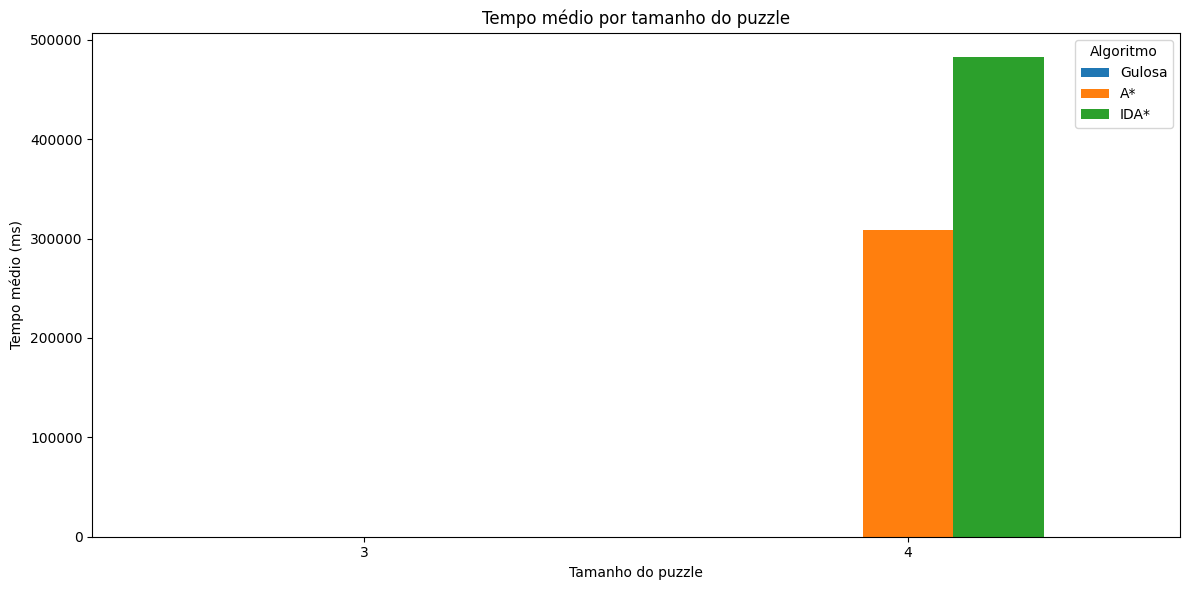

In [2]:
# Tempo médio por tamanho do puzzle
tempo_medio = (
    df.groupby(["tamanho_puzzle", "algoritmo"], observed=True)["tempo_ms"]
      .mean()
      .unstack()
      .reindex(columns=ordem_algoritmos)
)

ax = tempo_medio.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Tempo médio por tamanho do puzzle")
ax.set_xlabel("Tamanho do puzzle")
ax.set_ylabel("Tempo médio (ms)")
ax.legend(title="Algoritmo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

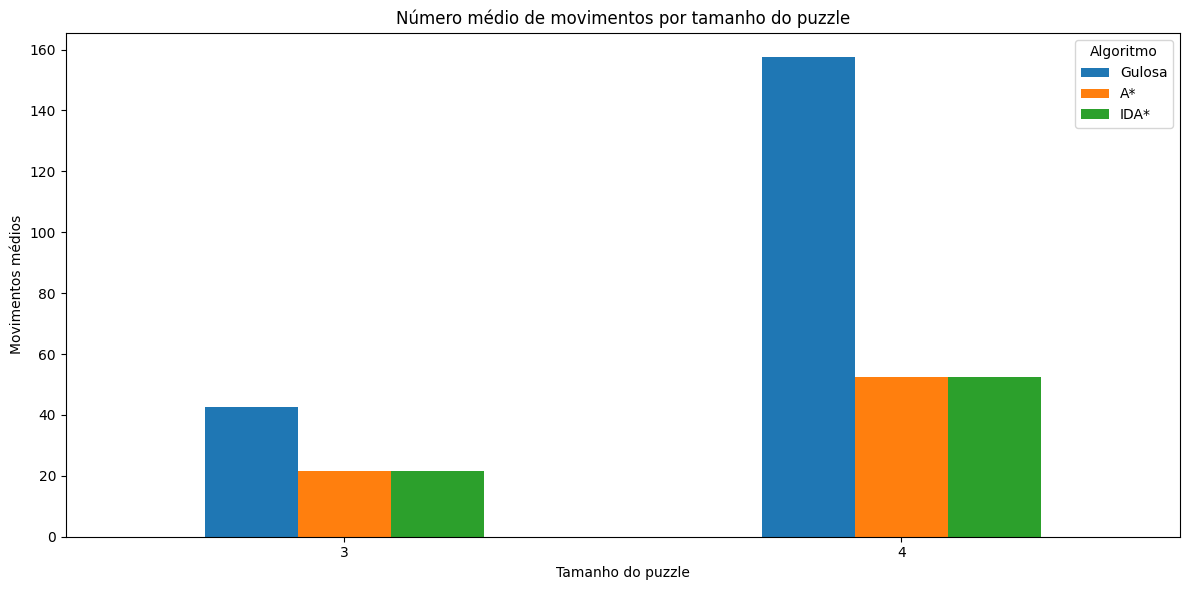

In [3]:
# Número médio de movimentos por tamanho do puzzle
movimentos_medio = (
    df.groupby(["tamanho_puzzle", "algoritmo"], observed=True)["movimentos"]
      .mean()
      .unstack()
      .reindex(columns=ordem_algoritmos)
)

ax = movimentos_medio.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Número médio de movimentos por tamanho do puzzle")
ax.set_xlabel("Tamanho do puzzle")
ax.set_ylabel("Movimentos médios")
ax.legend(title="Algoritmo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()